# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (roc_auc_score, roc_curve,
                             precision_recall_curve, classification_report,
                             confusion_matrix, average_precision_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

PROC   = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(exist_ok=True)

print("Imports OK")

Imports OK


# Load data & split

In [2]:
df = pd.read_csv(PROC / 'features_engineered.csv')

feature_cols = [c for c in df.columns if c != 'default_flag']
X = df[feature_cols]
y = df['default_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.2%}")
print(f"Test  default rate: {y_test.mean():.2%}")
print(f"Imbalance ratio: {(y_train==0).sum()}/{(y_train==1).sum()} = {(y_train==0).sum()/(y_train==1).sum():.1f}:1")

Train: (24000, 53)  |  Test: (6000, 53)
Train default rate: 22.12%
Test  default rate: 22.12%
Imbalance ratio: 18691/5309 = 3.5:1


# Handle class imbalance with SMOTE

In [3]:
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE → 0: {(y_train==0).sum():,}  |  1: {(y_train==1).sum():,}")
print(f"After  SMOTE → 0: {(y_train_res==0).sum():,}  |  1: {(y_train_res==1).sum():,}")

# IMPORTANT: always evaluate on the original (non-resampled) test set
print(f"\nTest set unchanged → 0: {(y_test==0).sum():,}  |  1: {(y_test==1).sum():,}")

Before SMOTE → 0: 18,691  |  1: 5,309
After  SMOTE → 0: 18,691  |  1: 9,345

Test set unchanged → 0: 4,673  |  1: 1,327


# Helper: full metrics suite

In [4]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name="Model"):
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)

    auc  = roc_auc_score(y_te, y_prob)
    gini = 2 * auc - 1
    ap   = average_precision_score(y_te, y_prob)

    # KS Statistic — most important metric in credit scoring
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    ks = (tpr - fpr).max()

    # CV AUC on training set
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_auc = cross_val_score(model, X_tr, y_tr,
                             cv=cv, scoring='roc_auc').mean()

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  ROC-AUC         : {auc:.4f}")
    print(f"  Gini            : {gini:.4f}")
    print(f"  KS Statistic    : {ks:.4f}")
    print(f"  Avg Precision   : {ap:.4f}")
    print(f"  CV AUC (5-fold) : {cv_auc:.4f}")
    print(f"{'='*45}")

    return {
        'name': name, 'auc': auc, 'gini': gini,
        'ks': ks, 'avg_precision': ap, 'cv_auc': cv_auc,
        'y_prob': y_prob, 'y_pred': y_pred
    }

# Train XGBoost (default params first)

In [7]:
xgb_base = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    eval_metric='auc',
    random_state=42,
    verbosity=0
    # early_stopping_rounds removed — incompatible with cross_val_score
)

xgb_base.fit(X_train_res, y_train_res)   # plain fit, no eval_set needed

xgb_base_results = evaluate_model(
    xgb_base, X_train_res, y_train_res,
    X_test, y_test, name="XGBoost (default)"
)


  XGBoost (default)
  ROC-AUC         : 0.8450
  Gini            : 0.6900
  KS Statistic    : 0.5142
  Avg Precision   : 0.6504
  CV AUC (5-fold) : 0.9170


# Train LightGBM (default params first)

In [8]:
lgb_base = lgb.LGBMClassifier(
    n_estimators=500,
    num_leaves=31,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

lgb_base.fit(X_train_res, y_train_res)

lgb_base_results = evaluate_model(
    lgb_base, X_train_res, y_train_res,
    X_test, y_test, name="LightGBM (default)"
)


  LightGBM (default)
  ROC-AUC         : 0.8463
  Gini            : 0.6926
  KS Statistic    : 0.5275
  Avg Precision   : 0.6505
  CV AUC (5-fold) : 0.9167


# Optuna tuning for XGBoost

In [9]:
def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 2.0),
        'scale_pos_weight':  (y_train==0).sum() / (y_train==1).sum(),
        'random_state':      42,
        'verbosity':         0,
        'eval_metric':       'auc',
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train_res, y_train_res,
                             cv=cv, scoring='roc_auc')
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=40,
                   show_progress_bar=True)

print(f"\nBest XGB AUC (CV): {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

  0%|          | 0/40 [00:00<?, ?it/s]


Best XGB AUC (CV): 0.9187
Best params: {'n_estimators': 743, 'max_depth': 8, 'learning_rate': 0.017505132935541165, 'subsample': 0.6383567373368426, 'colsample_bytree': 0.7790922387250476, 'min_child_weight': 6, 'gamma': 0.2533881284358336, 'reg_alpha': 0.4422279400571463, 'reg_lambda': 1.5844003073273418}


# Optuna tuning for LightGBM

In [10]:
def lgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 800),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 100),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 2.0),
        'class_weight':     'balanced',
        'random_state':     42,
        'verbose':          -1,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_res, y_train_res,
                             cv=cv, scoring='roc_auc')
    return scores.mean()

study_lgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lgb_objective, n_trials=40,
                   show_progress_bar=True)

print(f"\nBest LGB AUC (CV): {study_lgb.best_value:.4f}")
print(f"Best params: {study_lgb.best_params}")

  0%|          | 0/40 [00:00<?, ?it/s]


Best LGB AUC (CV): 0.9197
Best params: {'n_estimators': 795, 'num_leaves': 99, 'learning_rate': 0.01554746679261058, 'subsample': 0.8657091213231707, 'colsample_bytree': 0.665281379955129, 'min_child_samples': 42, 'reg_alpha': 0.2398480502600848, 'reg_lambda': 1.7412472930074463}


# Train tuned models & evaluate

In [11]:
# Train tuned XGBoost
xgb_tuned = xgb.XGBClassifier(
    **study_xgb.best_params,
    random_state=42, verbosity=0, eval_metric='auc'
)
xgb_tuned.fit(X_train_res, y_train_res)
xgb_tuned_results = evaluate_model(
    xgb_tuned, X_train_res, y_train_res,
    X_test, y_test, name="XGBoost (tuned)"
)

# Train tuned LightGBM
lgb_tuned = lgb.LGBMClassifier(
    **study_lgb.best_params,
    random_state=42, verbose=-1
)
lgb_tuned.fit(X_train_res, y_train_res)
lgb_tuned_results = evaluate_model(
    lgb_tuned, X_train_res, y_train_res,
    X_test, y_test, name="LightGBM (tuned)"
)


  XGBoost (tuned)
  ROC-AUC         : 0.8466
  Gini            : 0.6931
  KS Statistic    : 0.5186
  Avg Precision   : 0.6531
  CV AUC (5-fold) : 0.9185

  LightGBM (tuned)
  ROC-AUC         : 0.8456
  Gini            : 0.6912
  KS Statistic    : 0.5265
  Avg Precision   : 0.6515
  CV AUC (5-fold) : 0.9193


# Stacking ensemble

In [12]:
from sklearn.ensemble import StackingClassifier

stacker = StackingClassifier(
    estimators=[
        ('xgb', xgb_tuned),
        ('lgb', lgb_tuned),
    ],
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    cv=5,
    passthrough=False,
    n_jobs=-1
)

stacker.fit(X_train_res, y_train_res)
stacker_results = evaluate_model(
    stacker, X_train_res, y_train_res,
    X_test, y_test, name="Stacking Ensemble"
)


  Stacking Ensemble
  ROC-AUC         : 0.8468
  Gini            : 0.6937
  KS Statistic    : 0.5227
  Avg Precision   : 0.6544
  CV AUC (5-fold) : 0.9195


# Model comparison table + ROC curves

In [13]:
# Comparison table
all_results = [xgb_base_results, lgb_base_results,
               xgb_tuned_results, lgb_tuned_results, stacker_results]

comparison = pd.DataFrame([{
    'Model':         r['name'],
    'AUC':           round(r['auc'], 4),
    'Gini':          round(r['gini'], 4),
    'KS':            round(r['ks'], 4),
    'Avg Precision': round(r['avg_precision'], 4),
    'CV AUC':        round(r['cv_auc'], 4),
} for r in all_results])

print("\n--- Model Comparison ---")
print(comparison.to_string(index=False))

# Baselines for reference
print(f"\n  Logistic Regression (baseline) AUC: 0.8045")
print(f"  Decision Tree       (baseline) AUC: 0.8159")


--- Model Comparison ---
             Model    AUC   Gini     KS  Avg Precision  CV AUC
 XGBoost (default) 0.8450 0.6900 0.5142         0.6504  0.9170
LightGBM (default) 0.8463 0.6926 0.5275         0.6505  0.9167
   XGBoost (tuned) 0.8466 0.6931 0.5186         0.6531  0.9185
  LightGBM (tuned) 0.8456 0.6912 0.5265         0.6515  0.9193
 Stacking Ensemble 0.8468 0.6937 0.5227         0.6544  0.9195

  Logistic Regression (baseline) AUC: 0.8045
  Decision Tree       (baseline) AUC: 0.8159


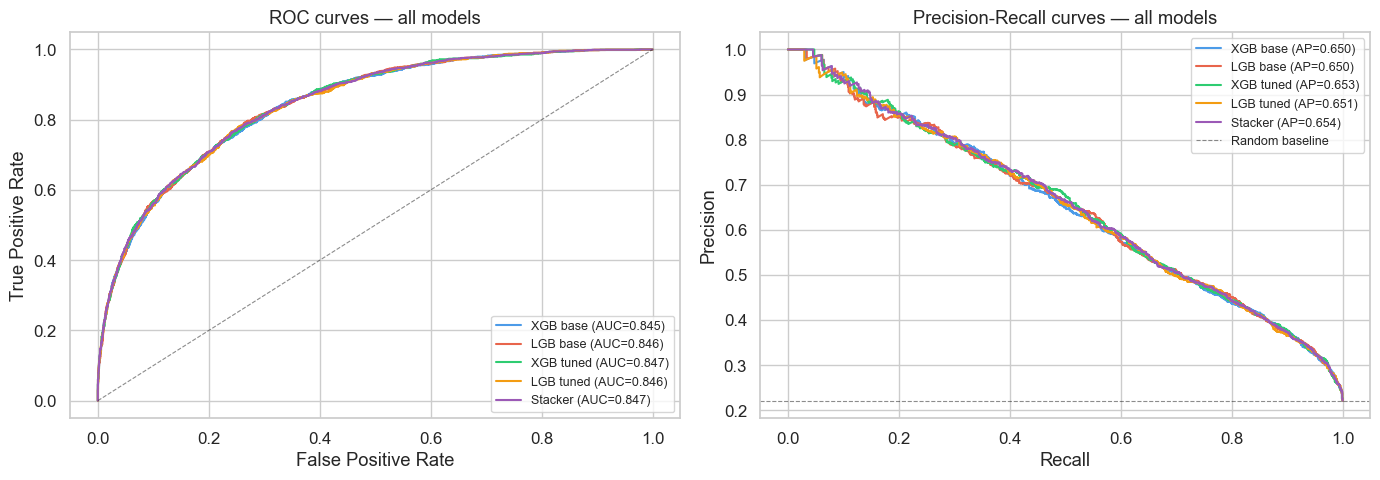

In [14]:
# ROC curves — all models on one chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C9BE8', '#E8654C', '#2ECC71', '#F39C12', '#9B59B6']
labels = ['XGB base', 'LGB base', 'XGB tuned', 'LGB tuned', 'Stacker']

for r, color, label in zip(all_results, colors, labels):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[0].plot(fpr, tpr, color=color, linewidth=1.5,
                 label=f"{label} (AUC={r['auc']:.3f})")

axes[0].plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curves — all models')
axes[0].legend(fontsize=9)

# Precision-Recall curves
for r, color, label in zip(all_results, colors, labels):
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    axes[1].plot(rec, prec, color=color, linewidth=1.5,
                 label=f"{label} (AP={r['avg_precision']:.3f})")

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--',
                linewidth=0.8, alpha=0.5, label='Random baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curves — all models')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP explainability

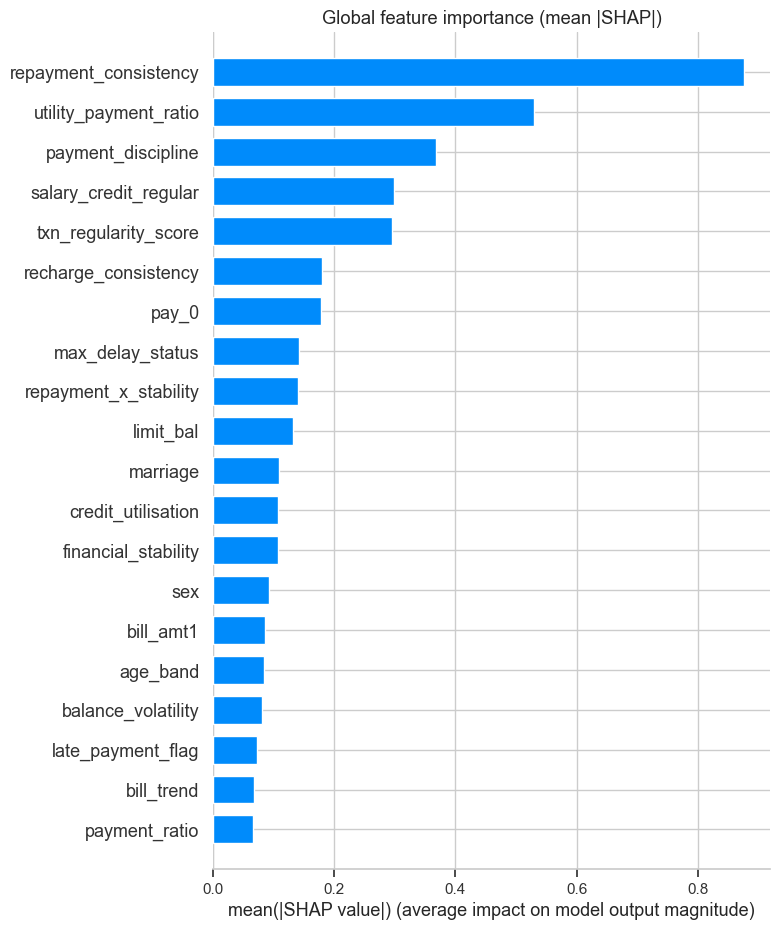

In [15]:
# Use best single model for SHAP
best_model = xgb_tuned   # swap to lgb_tuned if LGB scored higher

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Global summary — bar chart
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test,
                  plot_type='bar', show=False,
                  max_display=20)
plt.title('Global feature importance (mean |SHAP|)')
plt.tight_layout()
plt.savefig('../data/processed/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

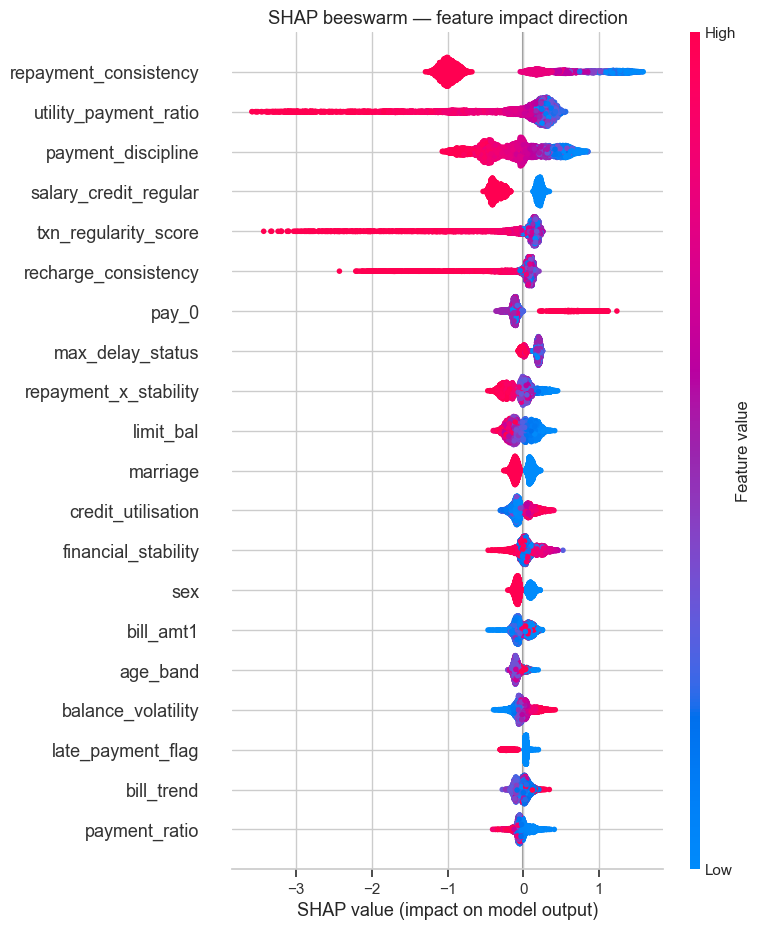

In [16]:
# Beeswarm plot — shows direction of impact too
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title('SHAP beeswarm — feature impact direction')
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

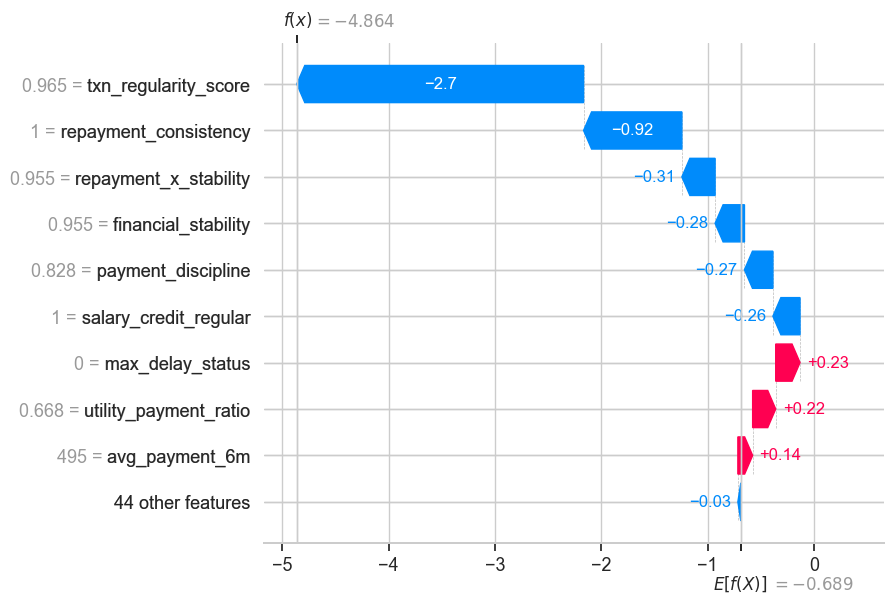

In [17]:
# Per-applicant waterfall — single prediction explained
sample_idx = 42   # any row from test set

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[sample_idx],
        base_values   = explainer.expected_value,
        data          = X_test.iloc[sample_idx],
        feature_names = feature_cols
    )
)

# Fairness audit

In [18]:
# Create proxy segments based on available features
segments = {
    'Young (age ≤ 25)':     X_test['age'] <= 25,
    'Mid (26–45)':          X_test['age'].between(26, 45),
    'Senior (age > 45)':    X_test['age'] > 45,
    'Low limit (< 50k)':    X_test['limit_bal'] < 50000,
    'High limit (≥ 200k)':  X_test['limit_bal'] >= 200000,
    'Low txn activity':     X_test['monthly_txn_count'] < 20,
    'High txn activity':    X_test['monthly_txn_count'] >= 60,
}

best_y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"\n{'Segment':<25}  {'N':>5}  {'Default%':>9}  {'AUC':>7}")
print("-" * 52)
for name, mask in segments.items():
    seg_y    = y_test[mask]
    seg_prob = best_y_prob[mask]
    if seg_y.nunique() < 2 or len(seg_y) < 30:
        print(f"{name:<25}  {'N/A':>5}  {'N/A':>9}  {'N/A':>7}")
        continue
    seg_auc = roc_auc_score(seg_y, seg_prob)
    print(f"{name:<25}  {len(seg_y):>5}  {seg_y.mean():>8.1%}  {seg_auc:>7.4f}")

print("\nTarget: AUC should not vary by more than 0.05 across segments.")


Segment                        N   Default%      AUC
----------------------------------------------------
Young (age ≤ 25)             767     25.6%   0.8512
Mid (26–45)                 4267     20.8%   0.8458
Senior (age > 45)            966     25.3%   0.8420
Low limit (< 50k)            871     34.3%   0.8388
High limit (≥ 200k)         2217     16.4%   0.8524
Low txn activity             N/A        N/A      N/A
High txn activity            101     19.8%   0.8333

Target: AUC should not vary by more than 0.05 across segments.


# Save artifacts

In [19]:
# Save the best models and explainer
joblib.dump(xgb_tuned,  MODELS / 'xgb_tuned.pkl')
joblib.dump(lgb_tuned,  MODELS / 'lgb_tuned.pkl')
joblib.dump(stacker,    MODELS / 'stacker.pkl')
joblib.dump(explainer,  MODELS / 'shap_explainer.pkl')

# Save feature names list for API
joblib.dump(feature_cols, MODELS / 'feature_cols.pkl')

# Save scaler (needed for LR in API fallback)
scaler = StandardScaler()
scaler.fit(X_train_res)
joblib.dump(scaler, MODELS / 'scaler.pkl')

# Save test set for dashboard
X_test.to_csv(PROC / 'X_test.csv', index=False)
y_test.to_csv(PROC / 'y_test.csv', index=False)

print("Saved:")
for f in MODELS.iterdir():
    size = f.stat().st_size / 1024
    print(f"  {f.name:<30} {size:>8.1f} KB")

Saved:
  feature_cols.pkl                    0.8 KB
  lgb_tuned.pkl                    8353.9 KB
  scaler.pkl                          3.1 KB
  shap_explainer.pkl              14719.3 KB
  stacker.pkl                     24354.1 KB
  xgb_tuned.pkl                    3820.6 KB


# Final summary table

In [22]:
baselines = {'Logistic Regression': 0.8045, 'Decision Tree': 0.8159}
for name, auc in baselines.items():
    print(f"  {name:<30} AUC: {auc:.4f}  (baseline)")

print()
for r in [xgb_tuned_results, lgb_tuned_results, stacker_results]:
    lift = r['auc'] - 0.8159
    print(f"  {r['name']:<30} AUC: {r['auc']:.4f}  KS: {r['ks']:.4f}  (+{lift:.4f} vs DT)")


  Logistic Regression            AUC: 0.8045  (baseline)
  Decision Tree                  AUC: 0.8159  (baseline)

  XGBoost (tuned)                AUC: 0.8466  KS: 0.5186  (+0.0307 vs DT)
  LightGBM (tuned)               AUC: 0.8456  KS: 0.5265  (+0.0297 vs DT)
  Stacking Ensemble              AUC: 0.8468  KS: 0.5227  (+0.0309 vs DT)
